### Predictive Modeling for Early Detection of Diabetes Using Machine Learning Techniques: A Case Study on the Pima Indians Diabetes Dataset

In [21]:
import numpy as np
import pandas as pd
import random
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint , uniform , loguniform

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# XGBoost and LightGBM
import xgboost as xgb
import lightgbm as lgb

# Version info
import sys
import sklearn
import imblearn
import xgboost
import lightgbm

# Ignore warnings
warnings.filterwarnings("ignore")

# Random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Library versions
print("Python:", sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)
print("xgboost:", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)


Python: 3.11.9 | packaged by conda-forge | (main, Apr 19 2024, 18:27:10) [MSC v.1938 64 bit (AMD64)]
numpy: 1.26.0
pandas: 2.2.3
scikit-learn: 1.5.1
imblearn: 0.12.3
xgboost: 3.0.0
lightgbm: 4.6.0


## 1. Data Loading

In [ ]:
df = pd.read_csv("D:\\Projects_Final\\Diabetes_Prediction\\data\\diabetes.csv")

## 2. EDA

In [23]:
print("Class Distribution:\n", df["Outcome"].value_counts())

Class Distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64


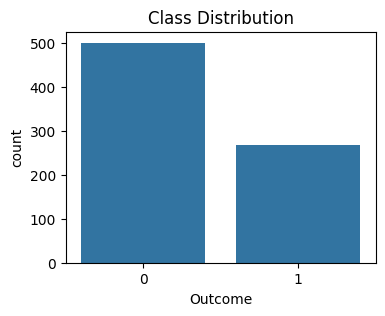

In [24]:
# Plot class balance
plt.figure(figsize=(4,3))
sns.countplot(x='Outcome', data=df)
plt.title("Class Distribution")
plt.show()

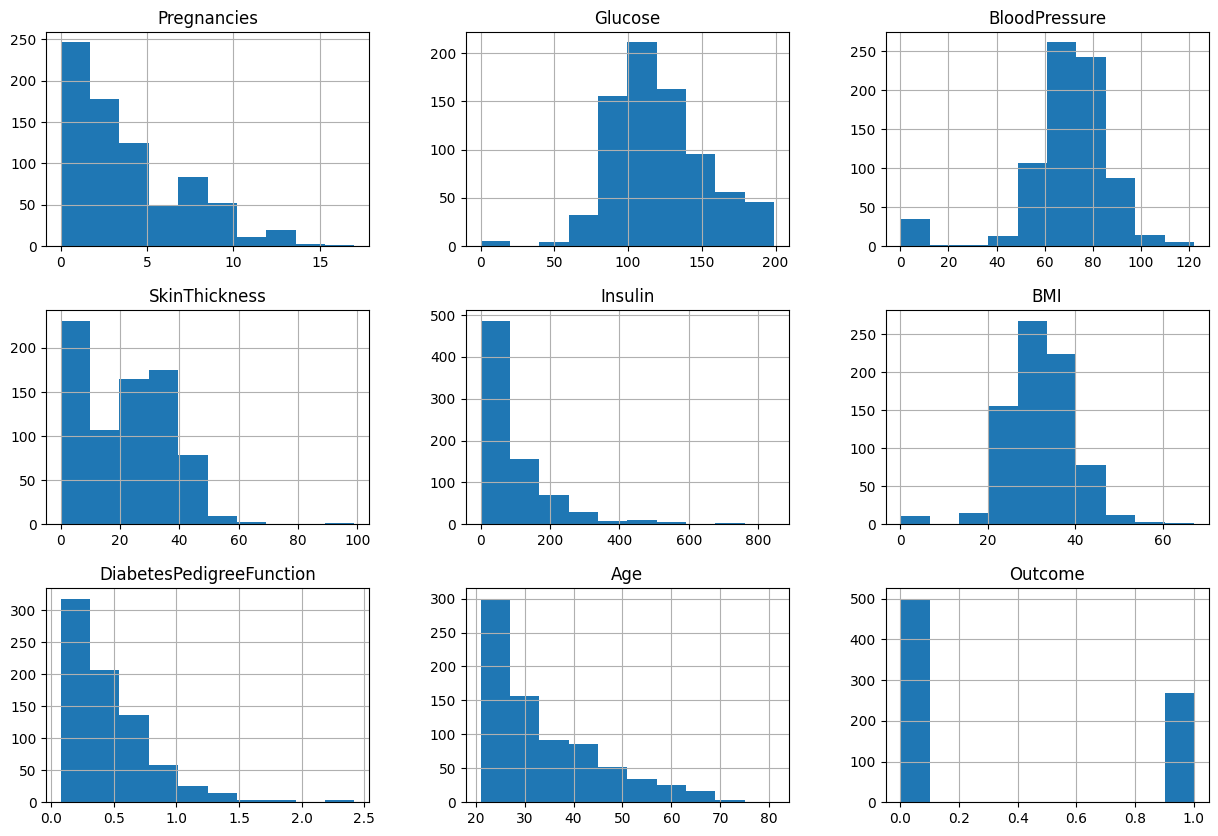

In [25]:
# Histograms
df.hist(figsize=(15,10))
plt.show()

In [26]:
cols = df.columns.tolist()
print(cols)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


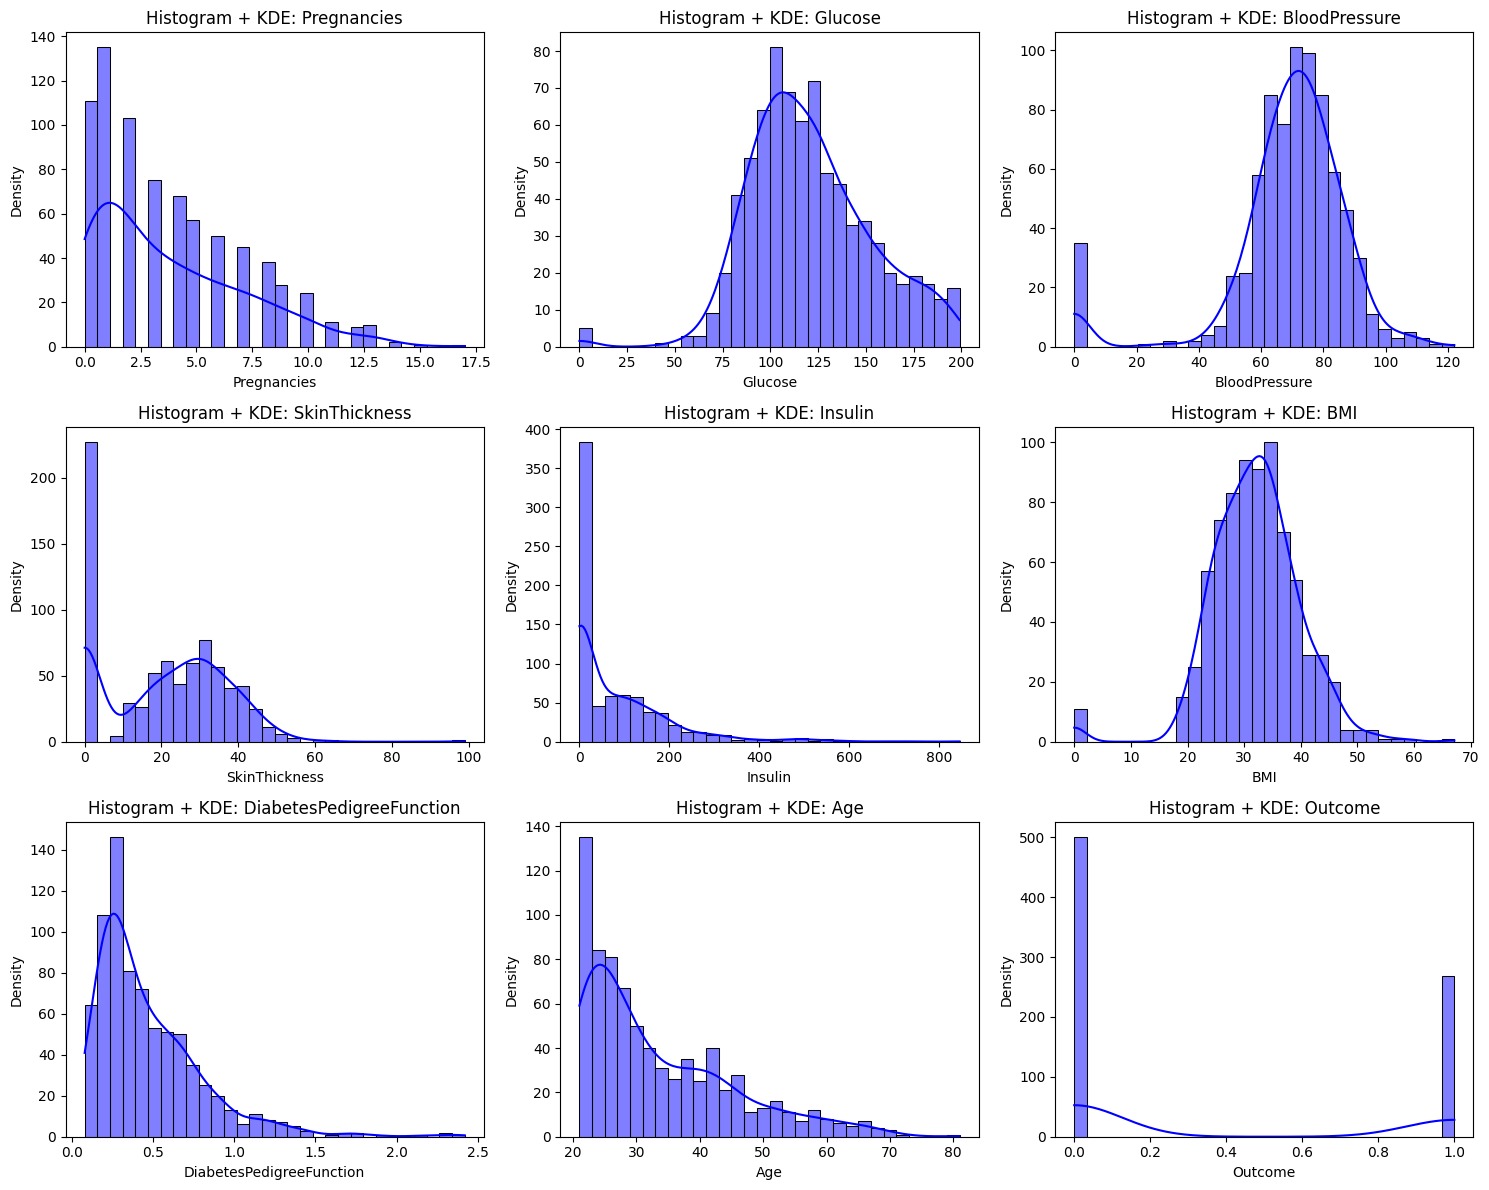

In [27]:
n_cols = len(cols)  # 9 for Pima dataset

# Set rows and columns for subplots
n_rows = (n_cols + 2) // 3  # Automatically calculate rows for 3 columns per row

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, 3, i + 1)
    sns.histplot(df[col], kde=True, color='blue', bins=30)
    plt.title(f'Histogram + KDE: {col}')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()


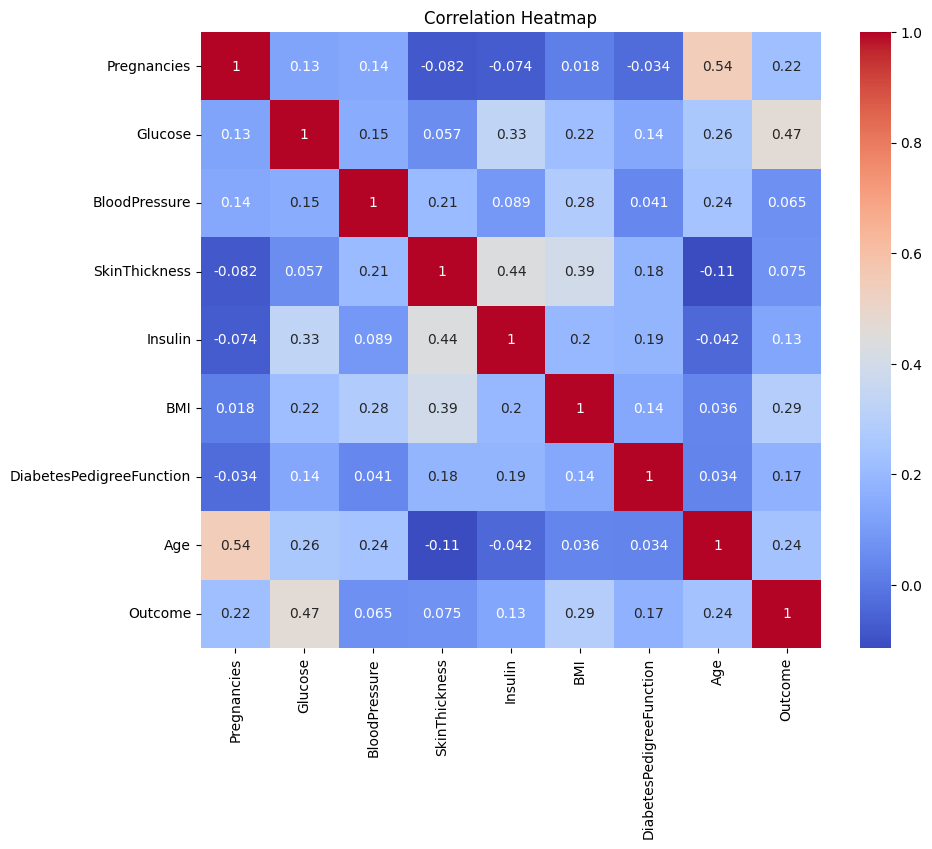

In [28]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 3. Outlier Analysis

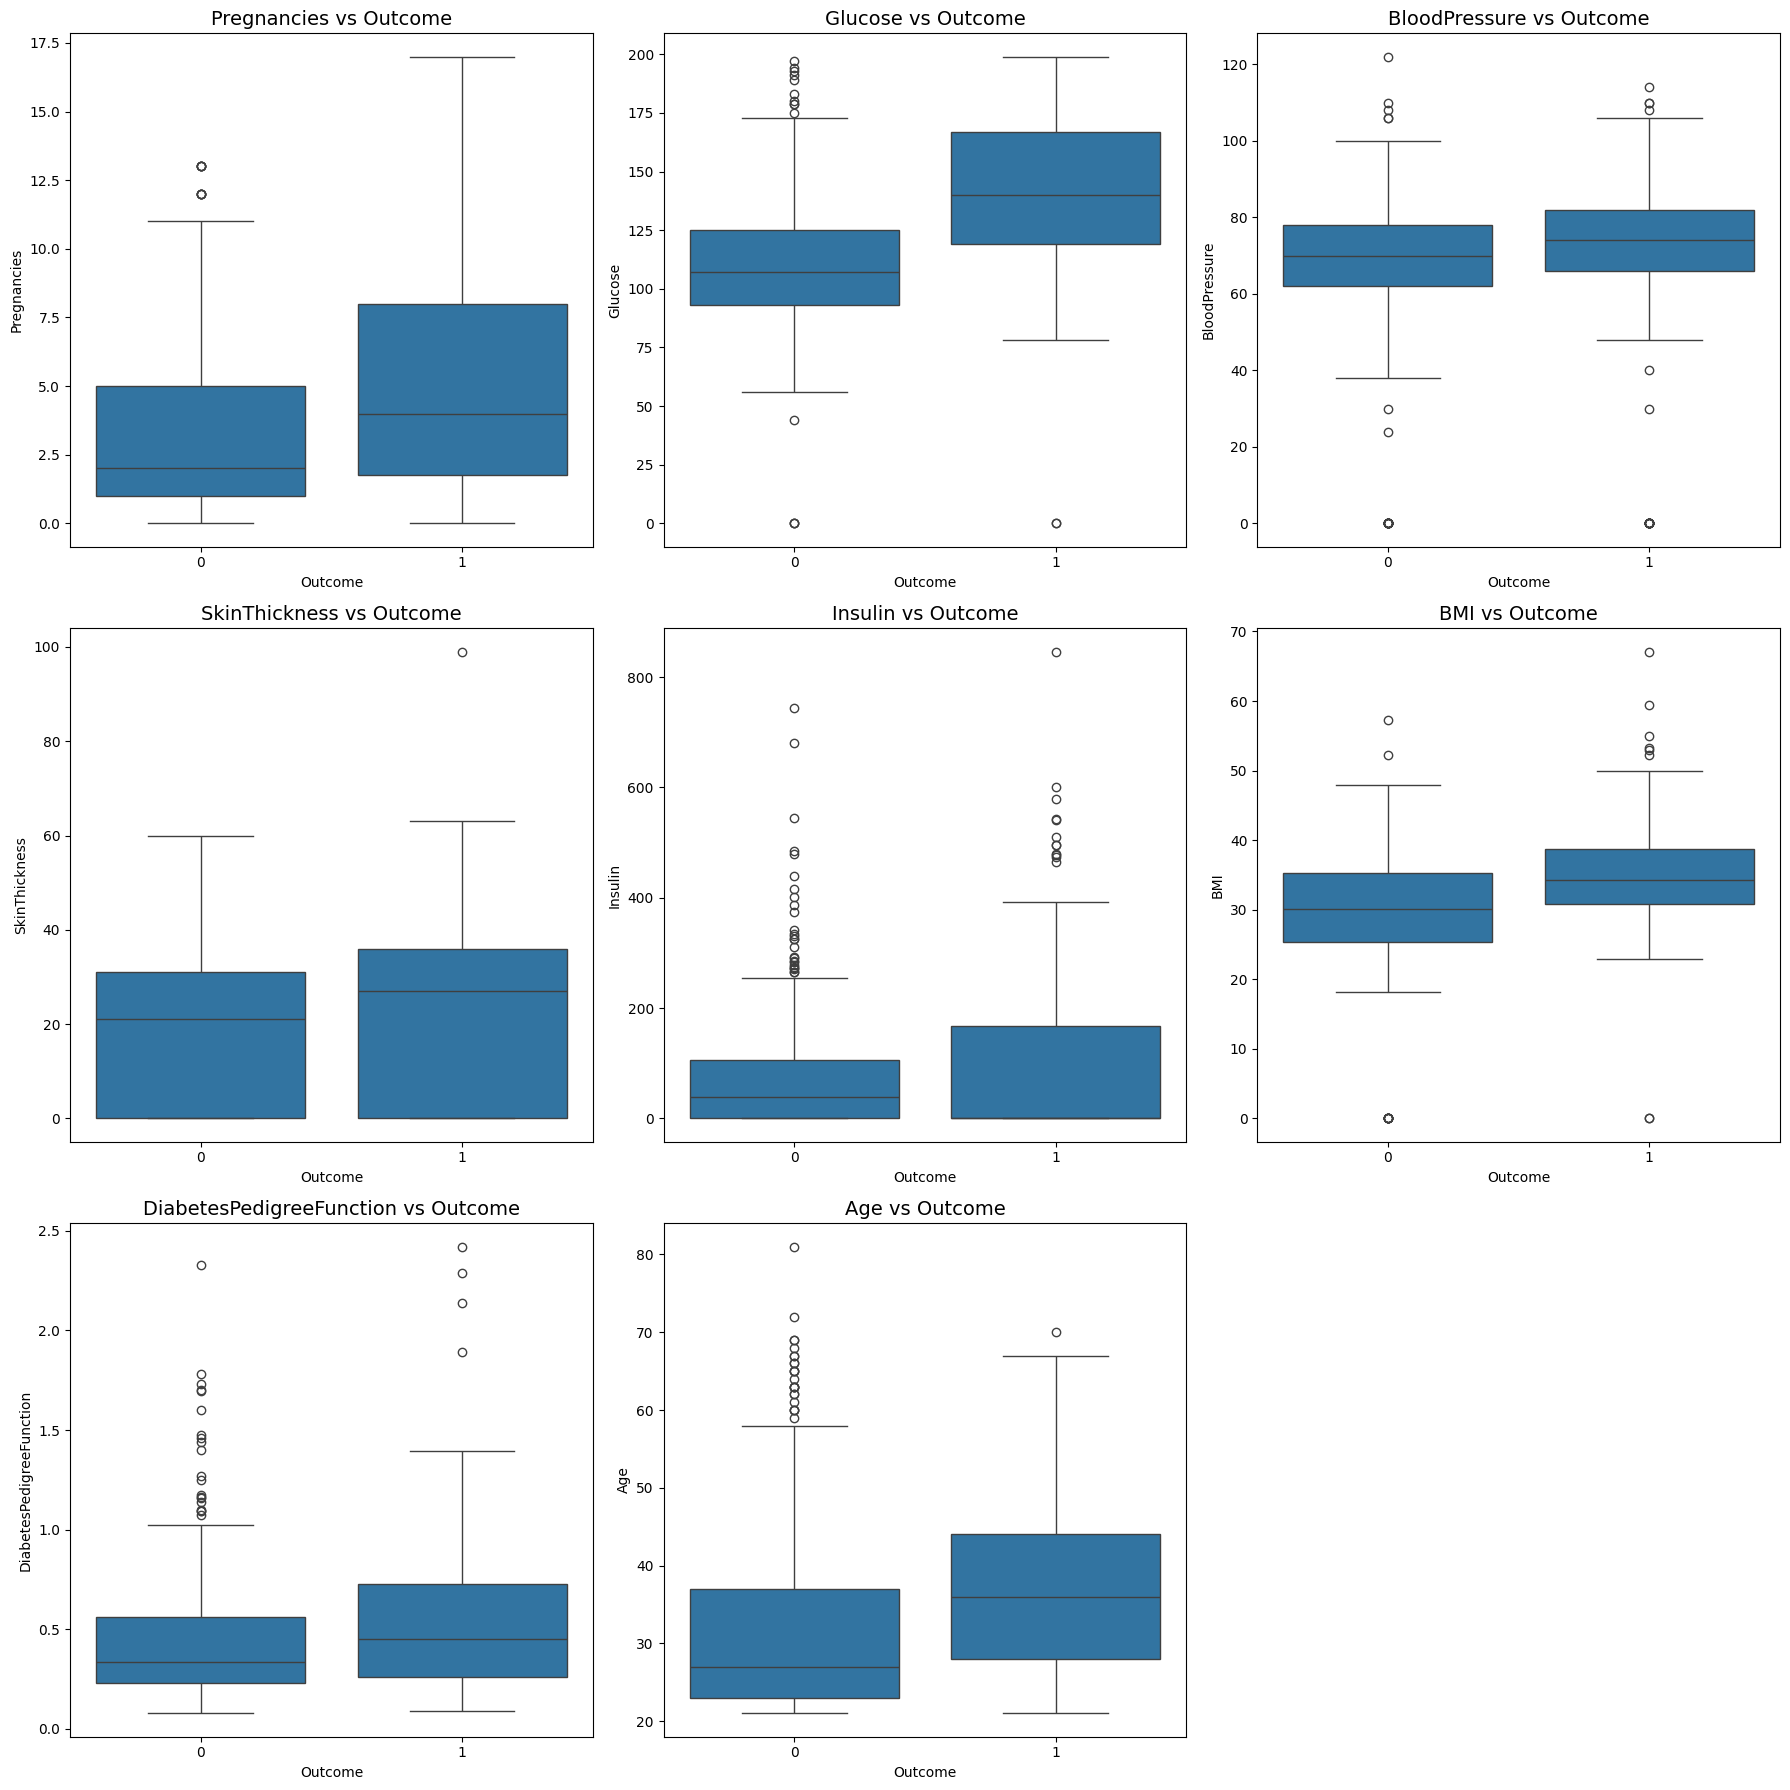

In [29]:
cols = df.columns[:-1]  # exclude 'Outcome' if it's the target
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(6* n_cols, 6* n_rows))  # dynamically scale figure size

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'{col} vs Outcome', fontsize=14)
    plt.xlabel('Outcome')
    plt.ylabel(col)

plt.tight_layout()
plt.show()



###  Zero Value Analysis & Replacement

In [30]:
# Cell 5 - Zero Analysis

cols_medical = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = (df[cols_medical] == 0).sum()
print("Zeros in columns:\n", zero_counts)

# Replace zeros with NaN
df[cols_medical] = df[cols_medical].replace(0, np.nan)

# Check how many values replaced
print("NaN counts after replacement:\n", df[cols_medical].isna().sum())


Zeros in columns:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
NaN counts after replacement:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## 4. Train Test Split

In [31]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

## 5. KNN Imputer

In [33]:
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Check for remaining NaNs
print("Remaining NaNs in train:", X_train_imputed.isna().sum().sum())
print("Remaining NaNs in test:", X_test_imputed.isna().sum().sum())


Remaining NaNs in train: 0
Remaining NaNs in test: 0


## 6. Data Standardization

In [34]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns)


## 7. SMOTE on Train Data

In [35]:
print("Before SMOTE:", y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", y_train_smote.value_counts())


Before SMOTE: Outcome
0    400
1    214
Name: count, dtype: int64
After SMOTE: Outcome
0    400
1    400
Name: count, dtype: int64


## 8. Model Evaluation function

In [36]:
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = (y_probs >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_probs = None

    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_probs) if y_probs is not None else None
    gmean = np.sqrt(sensitivity * specificity) if sensitivity and specificity else 0

    print(f"=== {model_name} ===")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print(f"Specificity: {specificity:.2f}")
    print(f"G-Mean: {gmean:.2f}")
    if auc:
        print(f"AUC: {auc:.2f}")
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1-Score": f1,
        "AUC": auc,
        "G-Mean": gmean
    }


## 9. Evaluate Baseline Models Orignal and SMOTE

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter= 250),
    "Decision Tree": DecisionTreeClassifier(criterion='gini', random_state=2),
    "SVM": SVC(probability=True, kernel = 'rbf',random_state= 2),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state= 75),
    "LightGBM": lgb.LGBMClassifier(random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE),
}

results_original = []
results_smote = []

# Original train/test
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    result = evaluate_model(model, X_test_scaled, y_test, f"{name} (Original)")
    results_original.append(result)

# SMOTE train / original test
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    result = evaluate_model(model, X_test_scaled, y_test, f"{name} (SMOTE)")
    results_smote.append(result)


=== Logistic Regression (Original) ===

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.80      0.77       100
           1       0.57      0.50      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154

Specificity: 0.80
G-Mean: 0.63
AUC: 0.81
=== Decision Tree (Original) ===

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.59      0.61      0.60        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154

Specificity: 0.77
G-Mean: 0.69
AUC: 0.69
=== SVM (Original) ===

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.84      

## 10. Compare Metrics Visually

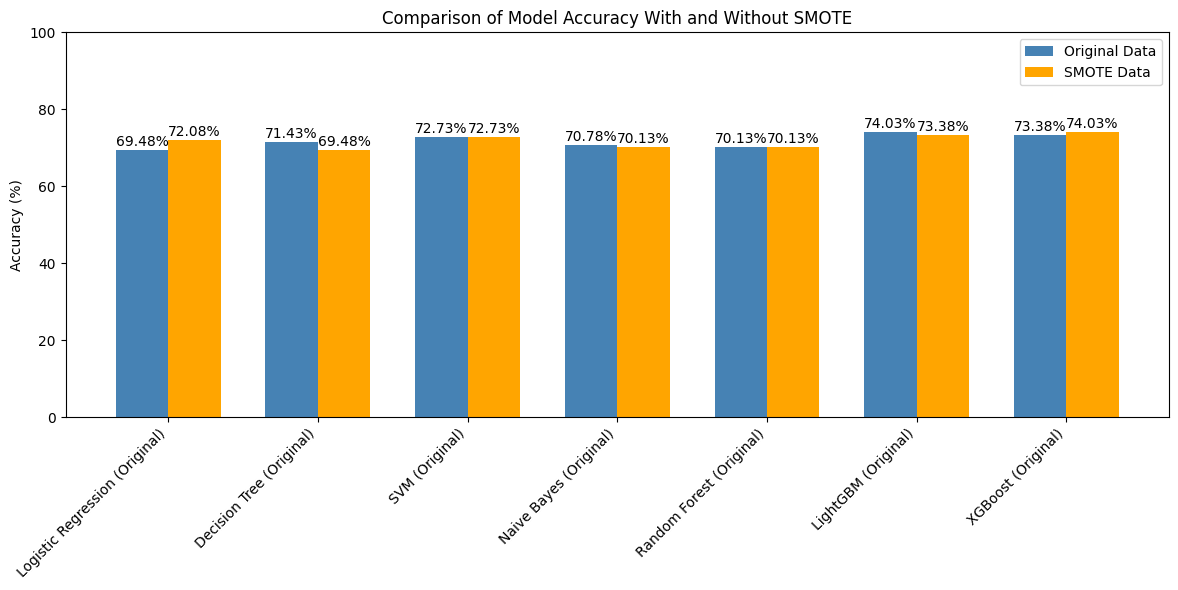

In [38]:
# Convert results into DataFrames
df_orig = pd.DataFrame(results_original)
df_smote = pd.DataFrame(results_smote)

# Ensure the same model order
models = df_orig["Model"].tolist()

# Extract the metric you want to plot
metric = "Accuracy"

# Multiply values by 100
accuracies_original = (df_orig[metric] * 100).tolist()
accuracies_smote = (df_smote[metric] * 100).tolist()

# Set up bar positions
x = np.arange(len(models))  # label locations
width = 0.35  # width of the bars

# Plotting
plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, accuracies_original, width, label='Original Data', color='steelblue')
bars2 = plt.bar(x + width/2, accuracies_smote, width, label='SMOTE Data', color='orange')

# Labels and title
plt.ylabel(f'{metric} (%)')
plt.title(f'Comparison of Model {metric} With and Without SMOTE')
plt.xticks(x, models, rotation=45, ha='right')
plt.ylim(0, 100)
plt.legend()

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}%', ha='center')

plt.tight_layout()
plt.show()


## 11. Hyperparameter Tuning 

In [39]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5, 10]
}

search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf,
    n_iter=5,
    cv=3,
    scoring='roc_auc',
    random_state=RANDOM_STATE
)

search_rf.fit(X_train_smote, y_train_smote)

best_rf = search_rf.best_estimator_
print("Best RF params:", search_rf.best_params_)


Best RF params: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None}


### 11.1 Define Hyperparameter Grids

In [40]:
"""param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5, 10]
}

param_grid_lgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63]
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}"""


"param_grid_rf = {\n    'n_estimators': [50, 100, 200],\n    'max_depth': [3, 5, None],\n    'min_samples_split': [2, 5, 10]\n}\n\nparam_grid_lgb = {\n    'n_estimators': [50, 100, 200],\n    'learning_rate': [0.01, 0.05, 0.1],\n    'num_leaves': [15, 31, 63]\n}\n\nparam_grid_xgb = {\n    'n_estimators': [50, 100, 200],\n    'learning_rate': [0.01, 0.05, 0.1],\n    'max_depth': [3, 5, 7]\n}"

In [41]:
param_grid_rf = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

param_grid_lgb = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(2, 20),
    'learning_rate': uniform(0.001, 0.2),
    'num_leaves': randint(20, 150)
}

param_grid_xgb = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(2, 20),
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(20, 150),
    'subsample': uniform(0.1, 0.9),          
    'colsample_bytree': uniform(0.1, 0.9),
}


### 11.2 RandomizedSearchCV Tuning Function

In [42]:
def tune_model(estimator, param_grid, X, y, model_name):
    search = RandomizedSearchCV(
        estimator,
        param_distributions=param_grid,
        n_iter=5,
        cv=3,
        scoring='roc_auc',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    search.fit(X, y)
    print(f"Best params for {model_name}: {search.best_params_}")
    return search.best_estimator_


### 11.3 Tune All Models (Original Data)

In [43]:
best_rf_orig = tune_model(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf,
    X_train_scaled,
    y_train,
    "Random Forest (Original)"
)

best_lgb_orig = tune_model(
    lgb.LGBMClassifier(random_state=RANDOM_STATE),
    param_grid_lgb,
    X_train_scaled,
    y_train,
    "LightGBM (Original)"
)

best_xgb_orig = tune_model(
    xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE),
    param_grid_xgb,
    X_train_scaled,
    y_train,
    "XGBoost (Original)"
)


Best params for Random Forest (Original): {'max_depth': 7, 'n_estimators': 485}
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 812
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

### 11.4 Tune All Models (SMOTE Data)

In [44]:
best_rf_smote = tune_model(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf,
    X_train_smote,
    y_train_smote,
    "Random Forest (SMOTE)"
)

best_lgb_smote = tune_model(
    lgb.LGBMClassifier(random_state=RANDOM_STATE),
    param_grid_lgb,
    X_train_smote,
    y_train_smote,
    "LightGBM (SMOTE)"
)

best_xgb_smote = tune_model(
    xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE),
    param_grid_xgb,
    X_train_smote,
    y_train_smote,
    "XGBoost (SMOTE)"
)


Best params for Random Forest (SMOTE): {'max_depth': 19, 'n_estimators': 264}
[LightGBM] [Info] Number of positive: 400, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

## 12. Evaluate Tuned Models

In [45]:
tuned_models = {
    "RF (Original)": (best_rf_orig, X_train_scaled, y_train, X_test_scaled, y_test),
    "LGBM (Original)": (best_lgb_orig, X_train_scaled, y_train, X_test_scaled, y_test),
    "XGB (Original)": (best_xgb_orig, X_train_scaled, y_train, X_test_scaled, y_test),
    "RF (SMOTE)": (best_rf_smote, X_train_smote, y_train_smote, X_test_scaled, y_test),
    "LGBM (SMOTE)": (best_lgb_smote, X_train_smote, y_train_smote, X_test_scaled, y_test),
    "XGB (SMOTE)": (best_xgb_smote, X_train_smote, y_train_smote, X_test_scaled, y_test)
}

results_tuned_train = []
results_tuned_test = []

for name, (model, Xtr, ytr, Xts, yts) in tuned_models.items():
    # Evaluate on train
    res_train = evaluate_model(model, Xtr, ytr, name + " Train")
    results_tuned_train.append(res_train)
    
    # Evaluate on test
    res_test = evaluate_model(model, Xts, yts, name + " Test")
    results_tuned_test.append(res_test)


=== RF (Original) Train ===

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95       400
           1       0.95      0.85      0.90       214

    accuracy                           0.93       614
   macro avg       0.94      0.91      0.92       614
weighted avg       0.93      0.93      0.93       614

Specificity: 0.97
G-Mean: 0.91
AUC: 0.99
=== RF (Original) Test ===

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80       100
           1       0.64      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154

Specificity: 0.83
G-Mean: 0.68
AUC: 0.81
=== LGBM (Original) Train ===

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.97      0.84      

### 13. Compare Tuned Models Visually

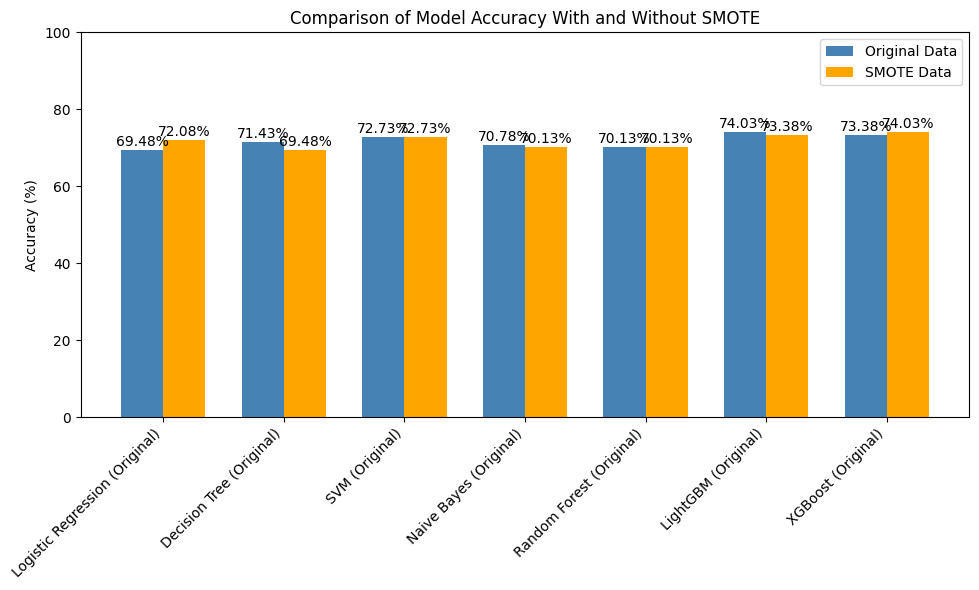

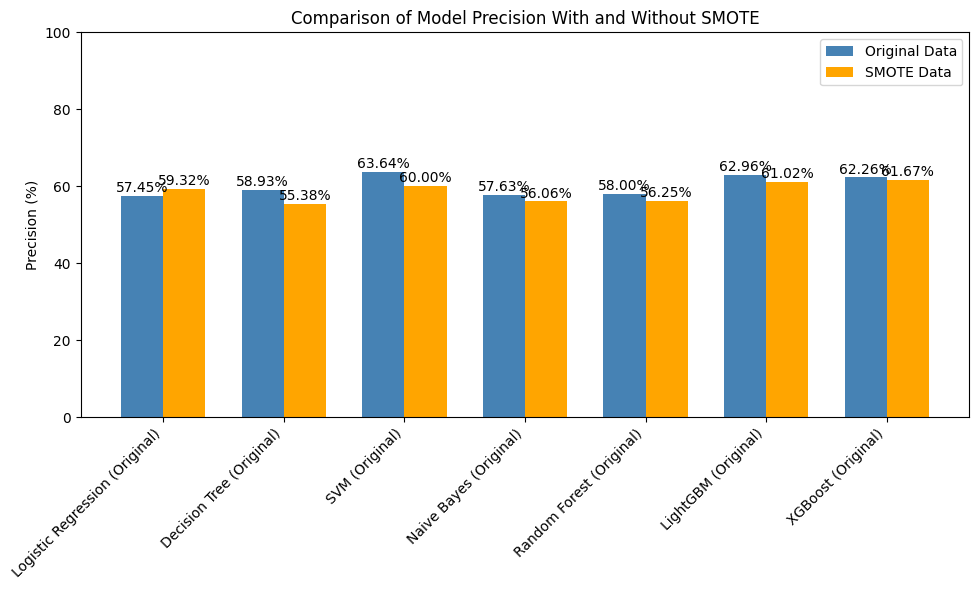

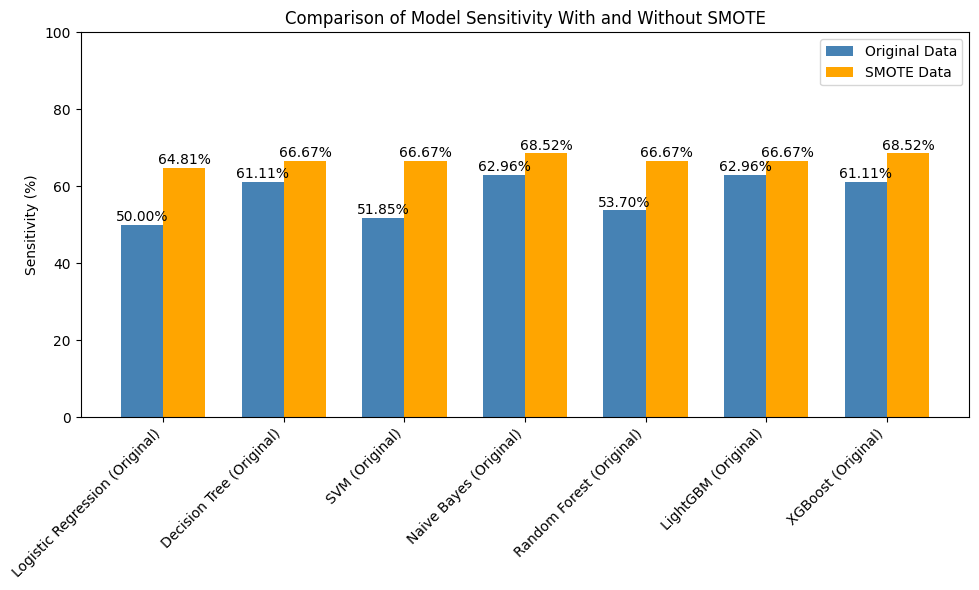

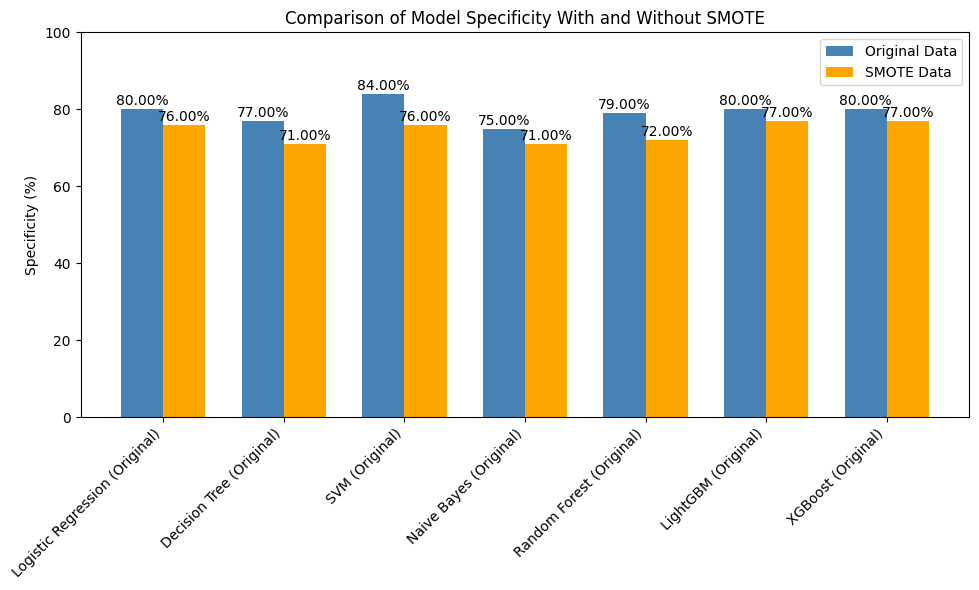

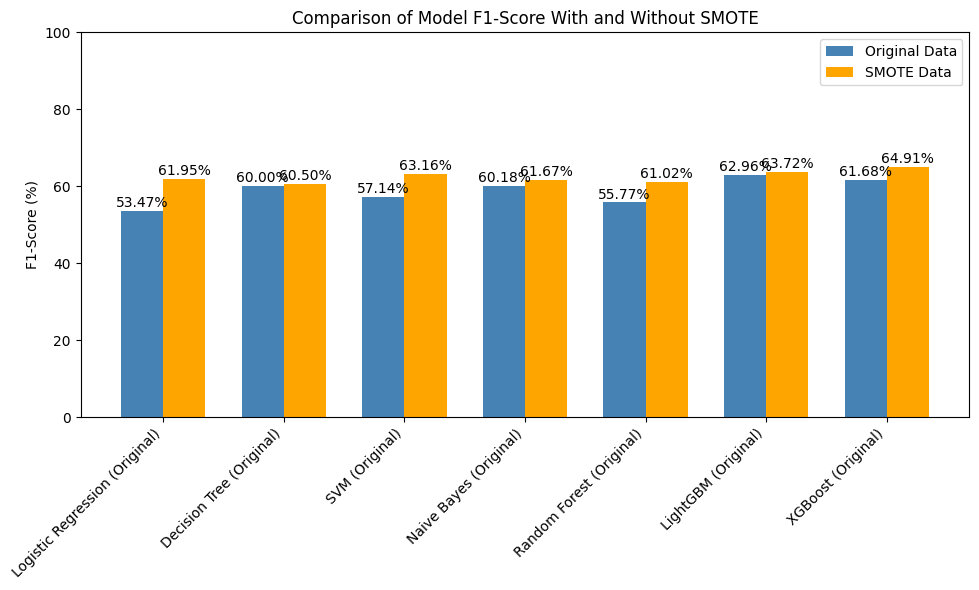

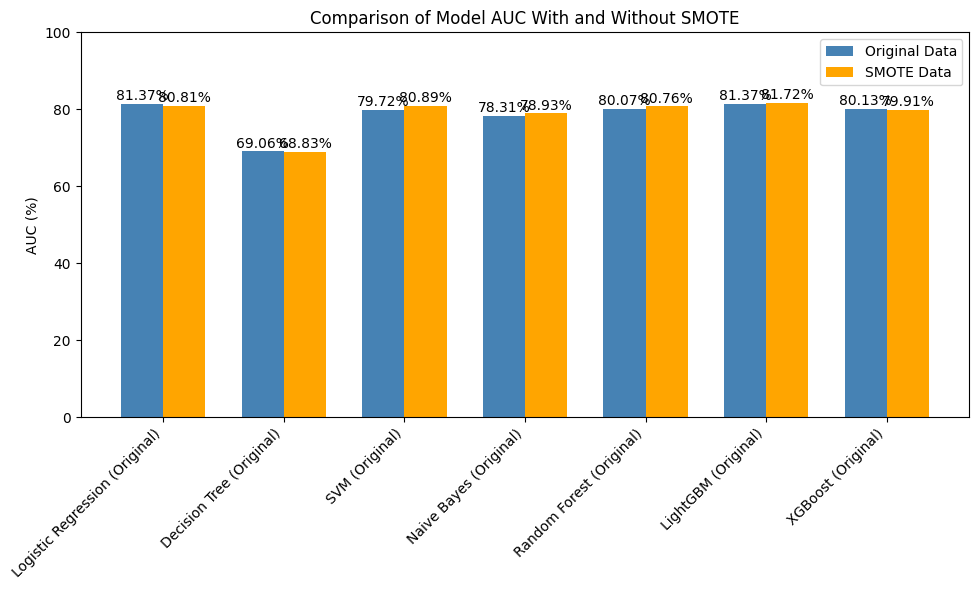

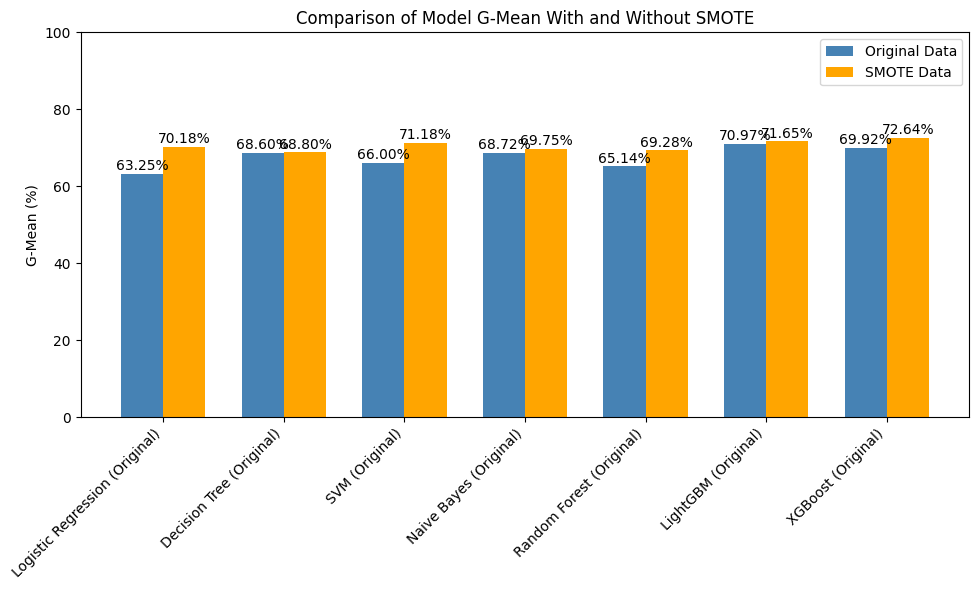

In [46]:
# Convert results into DataFrames
df_orig = pd.DataFrame(results_original)
df_smote = pd.DataFrame(results_smote)

# Ensure the same model order
models = df_orig["Model"].tolist()

# List of metrics to plot
metrics_to_plot = ["Accuracy", "Precision", "Sensitivity", "Specificity", "F1-Score", "AUC", "G-Mean"]

for metric in metrics_to_plot:
    # Multiply values by 100 for percentage display
    values_original = (df_orig[metric] * 100).tolist()
    values_smote = (df_smote[metric] * 100).tolist()

    # Set up bar positions
    x = np.arange(len(models))  # label locations
    width = 0.35  # width of the bars

    # Plotting
    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(x - width/2, values_original, width, label='Original Data', color='steelblue')
    bars2 = plt.bar(x + width/2, values_smote, width, label='SMOTE Data', color='orange')

    # Labels and title
    plt.ylabel(f'{metric} (%)')
    plt.title(f'Comparison of Model {metric} With and Without SMOTE')
    plt.xticks(x, models, rotation=45, ha='right')
    plt.ylim(0, 100)
    plt.legend()

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}%', ha='center')

    plt.tight_layout()
    plt.show()


## 16. Summary Tables

In [47]:
df_test = pd.DataFrame(results_tuned_test)

In [ ]:
from IPython.display import display

# Convert metrics to percentage
df_test_percent = df_test.copy()
for col in df_test.columns:
    if col not in ["Model"]:
        df_test_percent[col] = df_test[col] * 100

display(df_test_percent)


,Model,Accuracy,Precision,Sensitivity,Specificity,F1-Score,AUC,G-Mean
0,RF (Original) Test,73.376623,63.829787,55.555556,83.0,59.405941,81.277778,67.905163
1,LGBM (Original) Test,71.428571,75.000000,27.777778,95.0,40.540541,79.777778,51.370117
2,XGB (Original) Test,70.779221,58.490566,57.407407,78.0,57.943925,80.203704,66.916200
3,RF (SMOTE) Test,70.779221,57.377049,64.814815,74.0,60.869565,81.185185,69.255298
4,LGBM (SMOTE) Test,70.779221,57.627119,62.962963,75.0,60.176991,80.444444,68.718427
5,XGB (SMOTE) Test,68.181818,54.237288,59.259259,73.0,56.637168,79.000000,65.771771


In [63]:
import os

save_dir = r"D:\\Projects_Final\\Diabetes_Prediction\\results"
os.makedirs(save_dir, exist_ok=True)

file_path = os.path.join(save_dir, "tuned_models_test_results.csv")

df_test_percent.to_csv(file_path, index=False)

print("File saved successfully to:", file_path)


File saved successfully to: D:\\Projects_Final\\Diabetes_Prediction\\results\tuned_models_test_results.csv


## 14 Select Best Model

In [49]:
# Find best model row
best_model_row = df_test.loc[df_test["AUC"].idxmax()]
print("Best model overall:\n", best_model_row)

# Clean model name for lookup
model_name = best_model_row["Model"].replace(" Test", "").strip()

# Retrieve best model
best_model = tuned_models[model_name][0]


Best model overall:
 Model          RF (Original) Test
Accuracy                 0.733766
Precision                0.638298
Sensitivity              0.555556
Specificity                  0.83
F1-Score                 0.594059
AUC                      0.812778
G-Mean                   0.679052
Name: 0, dtype: object


In [50]:
# Calculate optimal threshold
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate G-mean for all thresholds
gmeans = np.sqrt(tpr * (1 - fpr))
ix = np.argmax(gmeans)
best_thresh = thresholds[ix]

print('Best Threshold = %.3f, G-Mean = %.3f' % (best_thresh, gmeans[ix]))


Best Threshold = 0.275, G-Mean = 0.752


##  15. Final Model Evaluation on Test Set

In [51]:
final_result = evaluate_model(
    best_model,
    X_test_scaled,
    y_test,
    "Best Model Final Test Evaluation",
    threshold=best_thresh
)
print(f"Final Result: {final_result}")

=== Best Model Final Test Evaluation ===

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.65      0.76       100
           1       0.57      0.87      0.69        54

    accuracy                           0.73       154
   macro avg       0.74      0.76      0.72       154
weighted avg       0.79      0.73      0.73       154

Specificity: 0.65
G-Mean: 0.75
AUC: 0.81
Final Result: {'Model': 'Best Model Final Test Evaluation', 'Accuracy': 0.7272727272727273, 'Precision': 0.573170731707317, 'Sensitivity': 0.8703703703703703, 'Specificity': 0.65, 'F1-Score': 0.6911764705882353, 'AUC': 0.8127777777777778, 'G-Mean': 0.7521573909367246}


In [62]:
import joblib
import os

save_dir = "D:\\Projects_Final\\Diabetes_Prediction\\models"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "pipeline.pkl")   # <-- Add filename here

joblib.dump(pipeline_objects, save_path)

print("Saved to:", save_path)


Saved to: D:\Projects_Final\Diabetes_Prediction\models\pipeline.pkl


## 13 User Input Prediction

In [53]:
# def user_predict(model, imputer, scaler):
#     feature_ranges = {
#         'Pregnancies': (0, 17),
#         'Glucose': (0, 199),
#         'BloodPressure': (0, 122),
#         'SkinThickness': (0, 99),
#         'Insulin': (0, 846),
#         'BMI': (0, 67.1),
#         'DiabetesPedigreeFunction': (0, 2.5),
#         'Age': (21, 81)
#     }
    
#     user_input = []
#     for feature, (min_val, max_val) in feature_ranges.items():
#         value = float(input(f"Enter {feature} (Range: {min_val}-{max_val}): "))
#         if value < min_val or value > max_val:
#             print(f"Warning: Value outside normal range.")
#         if feature in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'] and value == 0:
#             value = np.nan
#         user_input.append(value)
    
#     input_df = pd.DataFrame([user_input], columns=feature_ranges.keys())
#     input_df_imputed = pd.DataFrame(imputer.transform(input_df), columns=input_df.columns)
#     input_scaled = scaler.transform(input_df_imputed)
    
#     prediction = model.predict(input_scaled)[0]
#     prob = model.predict_proba(input_scaled)[0][1]
    
#     outcome = "Diabetic" if prediction == 1 else "Not Diabetic"
#     print(f"Prediction: {outcome}")
#     print(f"Probability: {prob:.2f}")


In [54]:
# feature_ranges = {
#     'Pregnancies': (0, 17),
#     'Glucose': (0, 199),
#     'BloodPressure': (0, 122),
#     'SkinThickness': (0, 99),
#     'Insulin': (0, 846),
#     'BMI': (0, 67.1),
#     'DiabetesPedigreeFunction': (0, 2.5),
#     'Age': (21, 81)
# }

# user_input = []

# print("\nPlease enter the following features one by one:\n")

# for feature, (min_val, max_val) in feature_ranges.items():
#     while True:
#         try:
#             value = input(f"Enter {feature} (Range: {min_val}-{max_val}): ").strip()
            
#             # Treat blank as missing
#             if value == "":
#                 value = np.nan
#                 break
#             else:
#                 value = float(value)
            
#             # Check bounds if numeric
#             if not pd.isna(value):
#                 if value < min_val or value > max_val:
#                     print(f"⚠️  {feature} = {value} is outside allowed range [{min_val}-{max_val}]. Please enter again.")
#                     continue
            
#             # Replace zero with NaN for medical features
#             if feature in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
#                 if value == 0:
#                     value = np.nan
#                     print(f"Note: Zero entered for {feature}. Interpreted as missing (NaN).")
            
#             user_input.append(value)
#             break
        
#         except ValueError:
#             print(f"⚠️ Invalid input. Please enter a numeric value for {feature}.")

# # Confirm collected inputs
# print("\nYour inputs collected:")
# for f, v in zip(feature_ranges.keys(), user_input):
#     print(f"  {f}: {v}")

# # Create DataFrame
# input_df = pd.DataFrame([user_input], columns=feature_ranges.keys())

# # Impute missing values
# input_df_imputed = pd.DataFrame(imputer.transform(input_df), columns=input_df.columns)

# # Scale input
# input_scaled = scaler.transform(input_df_imputed)

# # Predict
# prediction = best_model.predict(input_scaled)[0]

# if hasattr(best_model, "predict_proba"):
#     prob = best_model.predict_proba(input_scaled)[0][1]
# else:
#     prob = None

# outcome = "Diabetic" if prediction == 1 else "Not Diabetic"

# print("\n🌟 FINAL PREDICTION 🌟")
# print(f"Prediction: {outcome}")
# if prob is not None:
#     print(f"Probability of being diabetic: {prob:.2f}")
